## Binary Classification of Seizures in EEG Data

### Set Up

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import welch
from antropy import sample_entropy, perm_entropy, katz_fd
import scipy.stats as stats

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    mean_squared_error, mean_absolute_error)

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix)


from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import joblib

### Loading files

Data is preprocessed and comes from: https://www.kaggle.com/datasets/masahirogotoh/mit-chb-processed

In [2]:
data_dir = os.path.expanduser("~/Desktop/archive/")

signal_path = os.path.join(data_dir, "signal_samples.npy")
label_path  = os.path.join(data_dir, "is_sz.npy")

X_raw = np.load(signal_path) #shape: (n, 18, 2048)
y_ratio = np.load(label_path) # shape: (n,)

print("Raw X shape:", X_raw.shape) # (n, 18, 2048)
print("Raw y_ratio shape:", y_ratio.shape)

# Get seizure ratio, that is convert the window to a binary label: if any portion of the 8s window is seizure then its marked a seizure
y = (y_ratio > 0).astype(int)

print(f"Total samples: {len(y)}")
print(f"Seizure windows: {np.sum(y==1)}, Non-seizure: {np.sum(y==0)}")

Raw X shape: (9505, 18, 2048)
Raw y_ratio shape: (9505,)
Total samples: 9505
Seizure windows: 2581, Non-seizure: 6924


### Handling Class Imbalance

The dataset is highly imbalanced, with many more non-seizure windows than seizure windows. The majority class was undersampled in accordance with the Kaggle reference code: https://www.kaggle.com/code/ava225/15-channels-mit-chb, which we based parts of the pipeline on. 

In [4]:
seizure_segments     = X_raw[y == 1] # shape: (N_seiz, 18, 2048)
non_seizure_segments = X_raw[y == 0] # shape: (N_non, 18, 2048)

print(f"Seizure segments: {seizure_segments.shape[0]}")
print(f"Non-seizure segments: {non_seizure_segments.shape[0]}")

# Target: non-seizure = 2 * seizure (ratio 1:2)
n_seizure = seizure_segments.shape[0]
n_non_target = 2 * n_seizure

if non_seizure_segments.shape[0] > n_non_target:
    # downsample non-seizure
    idx = np.random.choice(non_seizure_segments.shape[0], n_non_target, replace=False)
    sampled_non_seizure_segments = non_seizure_segments[idx]
elif non_seizure_segments.shape[0] < n_non_target:
    # upsample non-seizure
    additional_needed = n_non_target - non_seizure_segments.shape[0]
    extra_idx = np.random.choice(non_seizure_segments.shape[0], additional_needed, replace=True)
    sampled_non_seizure_segments = np.vstack([non_seizure_segments, non_seizure_segments[extra_idx]])
else:
    sampled_non_seizure_segments = non_seizure_segments

sampled_non_seizure_labels = np.zeros(sampled_non_seizure_segments.shape[0])
seizure_labels             = np.ones(seizure_segments.shape[0])

all_segments = np.vstack([seizure_segments, sampled_non_seizure_segments])
all_labels   = np.concatenate([seizure_labels, sampled_non_seizure_labels])

print(f"Balanced total segments: {all_segments.shape[0]}")
print(f"Balanced seizure ratio: {np.mean(all_labels==1):.2f}")

Seizure segments: 2581
Non-seizure segments: 6924
Balanced total segments: 7743
Balanced seizure ratio: 0.33


-------

### Feature Extraction - Saved in a seperate file that can then be read directly

Each EEG window is turned into a list of numbers that describe it. For every channel, we measure basic things like how big the signal is, how much it changes, what the frequency content looks like, and how complex the signal is. Then we average these features across all channels so each window has one final feature vector. Based on: https://www.kaggle.com/code/ava225/15-channels-mit-chb

In [ ]:
def extract_features(segment):
    """ Extracts features from an EEG segment. For each channel, 12 time-domain statistics, 8 frequency-domain features and 3 non-linear features are computed. 
    The final feature vector is obtained by averaging the per-channel features."""
    _, n_samples = segment.shape
    features_per_channel = []

    for ch_data in segment:
        # 12 Time Domain Features
        time_stats = np.array([
            np.max(ch_data), np.min(ch_data), # max and min amplitude
            np.mean(ch_data), np.median(ch_data), # mean and median values
            np.std(ch_data),  np.var(ch_data), # standard dev and variance across the EEG signal 
            stats.kurtosis(ch_data), stats.skew(ch_data), #kurtosis (how heavy the tails are) and skewness (asymmetry of the distribution)
            np.sum(np.diff(np.sign(ch_data)) != 0), # zero-crossings
            np.sum(ch_data > 0) / len(ch_data), # proportion of positive samples
            np.max(ch_data) / np.min(ch_data) if np.min(ch_data) != 0 else 0, # max/min ratio
            np.mean(np.abs(ch_data)) # mean absolute value
        ])

        # 8 Frequency Domain Features via Welch PSD
        _, psd = welch(ch_data, fs=256, nperseg=n_samples)
        freq_stats = np.array([
            np.max(psd), np.min(psd), # max and min power
            np.mean(psd), np.median(psd), # mean and median power
            np.std(psd),  np.var(psd), # std and variance of power
            stats.kurtosis(psd), stats.skew(psd)
        ])

        # 3 Non-linear Features
        entropy_feats = np.array([
            sample_entropy(ch_data),
            perm_entropy(ch_data, order=3)
        ])
        complexity_feats = np.array([katz_fd(ch_data)])

        features_per_channel.append(np.concatenate([time_stats, freq_stats, entropy_feats, complexity_feats]))

    # Average feature vector across channels
    return np.mean(features_per_channel, axis=0)

print("Extracting features...")
all_features = np.array([extract_features(seg) for seg in all_segments])
print("Feature matrix shape:", all_features.shape) #(n_segments, n_features)

In [ ]:
# Saving features
np.save("X_features.npy", all_features)
np.save("y_labels.npy", all_labels)
print("Saved feature files: X_features.npy, y_labels.npy")

-----

In [5]:
# Reading the feature files that were saved earlier in the code
X = np.load("X_features.npy")
y = np.load("y_labels.npy")

In [7]:
# Replace missing values with the feature-wise mean
print(f"Original samples: {X.shape[0]}")
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
y = all_labels
print(f"Samples after imputation: {X.shape[0]}")

Original samples: 7743
Samples after imputation: 7743


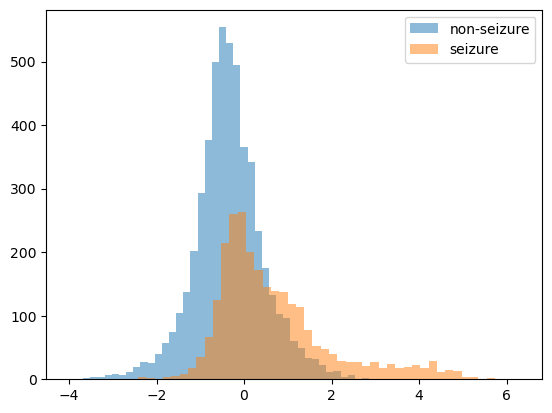

In [8]:
# LDA was used to inspect the feature distribution.
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)
plt.hist(X_lda[y==0], bins=50, alpha=0.5, label='non-seizure')
plt.hist(X_lda[y==1], bins=50, alpha=0.5, label='seizure')
plt.legend()
plt.show()

### Splitting Data 70/15/15

A dependent split is used (windows from the same patient can appear in train/val/test). SVM-based seizure studies often use this approach and show improved performance under this setup.

In [9]:
# 70/15/15 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1765, stratify=y_train, random_state=42)

# Printing info
print(f"Train: {X_train.shape[0]} "
      f"(seizures={np.sum(y_train==1)}, non-seizures={np.sum(y_train==0)})")
print(f"Val:   {X_val.shape[0]} "
      f"(seizures={np.sum(y_val==1)}, non-seizures={np.sum(y_val==0)})")
print(f"Test:  {X_test.shape[0]} "
      f"(seizures={np.sum(y_test==1)}, non-seizures={np.sum(y_test==0)})")


# Making all features similar in scale (fit on train, apply to val/test)
scaler_base = StandardScaler().fit(X_train)
X_train_s = scaler_base.transform(X_train)
X_val_s   = scaler_base.transform(X_val)
X_test_s  = scaler_base.transform(X_test)

Train: 5419 (seizures=1807, non-seizures=3612)
Val:   1162 (seizures=387, non-seizures=775)
Test:  1162 (seizures=387, non-seizures=775)


### Helper function

In [10]:
def eval_on_val(clf, X_tr, y_tr, X_val, y_val, name="model"):
    """Train the model and evaluate it on the validation set for hyperparameter tuning. 
       Returns accuracy, precision, recall, F1 and AUC."""
    clf.fit(X_tr, y_tr)
    y_val_pred = clf.predict(X_val)

    # Handing the predict_proba, so the function can be used for many different models
    if hasattr(clf, "predict_proba"):
        y_val_proba = clf.predict_proba(X_val)[:, 1]
        val_auc = roc_auc_score(y_val, y_val_proba)
    else:
        val_auc = np.nan

    val_acc  = accuracy_score(y_val, y_val_pred)
    val_prec = precision_score(y_val, y_val_pred, zero_division=0)
    val_rec  = recall_score(y_val, y_val_pred, zero_division=0)
    val_f1   = f1_score(y_val, y_val_pred, zero_division=0)

    print(f"{name}: Val Acc={val_acc:.3f}, Prec={val_prec:.3f}, "
          f"Rec={val_rec:.3f}, F1={val_f1:.3f}, AUC={val_auc if not np.isnan(val_auc) else -1:.3f}")

    return {
        "val_accuracy": val_acc,
        "val_precision": val_prec,
        "val_recall": val_rec,
        "val_f1": val_f1,
        "val_auc": val_auc,
    }

### SVM

The code below performs a grid search over the SVM hyperparameters (C and gamma) to find the best model, resulting in a total of 9 SVM model configurations.

In [11]:
svm_results = []
best_svm = None
best_svm_score = -np.inf
best_svm_params = None

C_values_svm     = [0.1, 1.0, 10.0]
gamma_values_svm = ["scale", 0.01, 0.1]

for C in C_values_svm:
    for gamma in gamma_values_svm:
        print(f"\nTesting C={C}, gamma={gamma}")
        svm = SVC(kernel="rbf", C=C, gamma=gamma, probability=True, random_state=42)
        
        metrics = eval_on_val(svm, X_train_s, y_train, X_val_s, y_val, name="SVM")

        row = {"C": C, "gamma": gamma}
        row.update(metrics)
        svm_results.append(row)

        # choose best by validation F1
        score = metrics["val_f1"]
        if score > best_svm_score:
            best_svm_score = score
            best_svm_params = (C, gamma)
            best_svm = svm

svm_results_df = pd.DataFrame(svm_results)
print("\n=== SVM validation results (sorted by F1) ===")
print(svm_results_df.sort_values("val_f1", ascending=False).to_string(index=False))
print(f"\nBest SVM params: C={best_svm_params[0]}, gamma={best_svm_params[1]}, F1={best_svm_score:.3f}")


Testing C=0.1, gamma=scale
SVM: Val Acc=0.743, Prec=0.778, Rec=0.318, F1=0.451, AUC=0.816

Testing C=0.1, gamma=0.01
SVM: Val Acc=0.726, Prec=0.835, Rec=0.222, F1=0.351, AUC=0.783

Testing C=0.1, gamma=0.1
SVM: Val Acc=0.745, Prec=0.769, Rec=0.336, F1=0.468, AUC=0.827

Testing C=1.0, gamma=scale
SVM: Val Acc=0.782, Prec=0.748, Rec=0.522, F1=0.615, AUC=0.860

Testing C=1.0, gamma=0.01
SVM: Val Acc=0.752, Prec=0.786, Rec=0.351, F1=0.486, AUC=0.829

Testing C=1.0, gamma=0.1
SVM: Val Acc=0.809, Prec=0.774, Rec=0.602, F1=0.677, AUC=0.872

Testing C=10.0, gamma=scale
SVM: Val Acc=0.823, Prec=0.791, Rec=0.636, F1=0.705, AUC=0.886

Testing C=10.0, gamma=0.01
SVM: Val Acc=0.785, Prec=0.775, Rec=0.499, F1=0.607, AUC=0.866

Testing C=10.0, gamma=0.1
SVM: Val Acc=0.831, Prec=0.780, Rec=0.687, F1=0.731, AUC=0.887

=== SVM validation results (sorted by F1) ===
   C gamma  val_accuracy  val_precision  val_recall   val_f1  val_auc
10.0   0.1      0.831325       0.780059    0.687339 0.730769 0.887197


### Logistic Regression 

The code below performs a grid search over different values of C to find the best Logistic Regression model, resulting in a total of 4 model configurations.

In [12]:
lr_results = []
best_lr = None
best_lr_score = -np.inf
best_lr_C = None

C_values_lr = [0.01, 0.1, 1.0, 10.0]

for C in C_values_lr:
    print(f"\nTesting C={C}")
    lr = LogisticRegression(
        C=C,
        max_iter=1000,
        solver="liblinear",
        random_state=42
    )
    metrics = eval_on_val(lr, X_train_s, y_train, X_val_s, y_val, name="LR")

    row = {"C": C}
    row.update(metrics)
    lr_results.append(row)

    score = metrics["val_f1"]
    if score > best_lr_score:
        best_lr_score = score
        best_lr_C = C
        best_lr = lr

lr_results_df = pd.DataFrame(lr_results)
print("\n=== Logistic Regression validation results (sorted by F1) ===")
print(lr_results_df.sort_values("val_f1", ascending=False).to_string(index=False))
print(f"\nBest LR C: {best_lr_C}, F1={best_lr_score:.3f}")


Testing C=0.01
LR: Val Acc=0.724, Prec=0.683, Rec=0.318, F1=0.434, AUC=0.749

Testing C=0.1
LR: Val Acc=0.729, Prec=0.680, Rec=0.351, F1=0.463, AUC=0.756

Testing C=1.0
LR: Val Acc=0.732, Prec=0.686, Rec=0.362, F1=0.474, AUC=0.756

Testing C=10.0
LR: Val Acc=0.736, Prec=0.698, Rec=0.364, F1=0.479, AUC=0.756

=== Logistic Regression validation results (sorted by F1) ===
    C  val_accuracy  val_precision  val_recall   val_f1  val_auc
10.00      0.735800       0.698020    0.364341 0.478778 0.756346
 1.00      0.732358       0.686275    0.361757 0.473773 0.755852
 0.10      0.728916       0.680000    0.351421 0.463373 0.755629
 0.01      0.723752       0.683333    0.317829 0.433862 0.748781

Best LR C: 10.0, F1=0.479


### Random Forest

The code below searches over different numbers of trees, maximum depths and minimum leaf sizes to find the best Random Forest model, evaluating a total of 12 model configurations.

In [26]:
rf_results = []
best_rf = None
best_rf_score = -np.inf
best_rf_params = None

n_estimators_rf = [100, 300]
max_depth_rf    = [None, 10, 20]
min_samples_leaf_rf = [1, 2]

for n_estimators in n_estimators_rf:
    for max_depth in max_depth_rf:
        for min_leaf in min_samples_leaf_rf:
            print(f"\nTesting n_estimators={n_estimators}, max_depth={max_depth}, min_leaf={min_leaf}")
            rf = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_leaf,
                random_state=42,
                n_jobs=-1
            )
            metrics = eval_on_val(rf, X_train, y_train, X_val, y_val, name="RF")

            row = {
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "min_samples_leaf": min_leaf
            }
            row.update(metrics)
            rf_results.append(row)

            score = metrics["val_f1"]
            if score > best_rf_score:
                best_rf_score = score
                best_rf_params = (n_estimators, max_depth, min_leaf)
                best_rf = rf

rf_results_df = pd.DataFrame(rf_results)
print("\n=== Random Forest validation results (sorted by F1) ===")
print(rf_results_df.sort_values("val_f1", ascending=False).to_string(index=False))
print(f"\nBest RF params: n_estimators={best_rf_params[0]}, max_depth={best_rf_params[1]}, "
      f"min_samples_leaf={best_rf_params[2]}, F1={best_rf_score:.3f}")


Testing n_estimators=100, max_depth=None, min_leaf=1
RF: Val Acc=0.837, Prec=0.806, Rec=0.674, F1=0.734, AUC=0.907

Testing n_estimators=100, max_depth=None, min_leaf=2
RF: Val Acc=0.826, Prec=0.785, Rec=0.659, F1=0.716, AUC=0.907

Testing n_estimators=100, max_depth=10, min_leaf=1
RF: Val Acc=0.818, Prec=0.807, Rec=0.594, F1=0.685, AUC=0.895

Testing n_estimators=100, max_depth=10, min_leaf=2
RF: Val Acc=0.818, Prec=0.801, Rec=0.605, F1=0.689, AUC=0.893

Testing n_estimators=100, max_depth=20, min_leaf=1
RF: Val Acc=0.834, Prec=0.801, Rec=0.667, F1=0.728, AUC=0.905

Testing n_estimators=100, max_depth=20, min_leaf=2
RF: Val Acc=0.830, Prec=0.789, Rec=0.667, F1=0.723, AUC=0.905

Testing n_estimators=300, max_depth=None, min_leaf=1
RF: Val Acc=0.832, Prec=0.794, Rec=0.669, F1=0.727, AUC=0.910

Testing n_estimators=300, max_depth=None, min_leaf=2
RF: Val Acc=0.830, Prec=0.793, Rec=0.661, F1=0.721, AUC=0.908

Testing n_estimators=300, max_depth=10, min_leaf=1
RF: Val Acc=0.820, Prec=0.80

### Gradient Boosting

The following code performs a grid search over several Gradient Boosting hyperparameters (learning rate, number of estimators, tree depth, subsampling rate and max features). In total, 72 model configurations are evaluated.

In [ ]:
gb_results = []
best_gb = None
best_gb_score = -np.inf
best_gb_params = None

learning_rates_gb = [0.1, 0.05]
n_estimators_gb   = [1000, 1500, 2000]
max_depth_gb      = [3, 4, 5]
subsamples_gb     = [1.0, 0.8]
max_features_gb   = ["sqrt", None]

for lr in learning_rates_gb:
    for n_estimators in n_estimators_gb:
        for depth in max_depth_gb:
            for subsample in subsamples_gb:
                for max_feat in max_features_gb:
                    print(f"\nTesting lr={lr}, n_estimators={n_estimators}, "
                          f"max_depth={depth}, subsample={subsample}, max_features={max_feat}")
                    
                    gb = GradientBoostingClassifier(
                        learning_rate=lr,
                        n_estimators=n_estimators,
                        max_depth=depth,
                        subsample=subsample,
                        max_features=max_feat,
                        random_state=42
                    )
                    
                    metrics = eval_on_val(gb, X_train_s, y_train, X_val_s,   y_val,name="GB")

                    row = {
                        "learning_rate": lr,
                        "n_estimators": n_estimators,
                        "max_depth": depth,
                        "subsample": subsample,
                        "max_features": max_feat
                    }
                    row.update(metrics)
                    gb_results.append(row)

                    score = metrics["val_f1"]
                    if score > best_gb_score:
                        best_gb_score = score
                        best_gb_params = (lr, n_estimators, depth, subsample, max_feat)
                        best_gb = gb

gb_results_df = pd.DataFrame(gb_results)
print("\n=== Gradient Boosting validation results (sorted by F1) ===")
print(gb_results_df.sort_values("val_f1", ascending=False).to_string(index=False))
print(
    f"\nBest GB params: "
    f"lr={best_gb_params[0]}, "
    f"n_estimators={best_gb_params[1]}, "
    f"max_depth={best_gb_params[2]}, "
    f"subsample={best_gb_params[3]}, "
    f"max_features={best_gb_params[4]}, "
    f"F1={best_gb_score:.3f}"
)


Testing lr=0.1, n_estimators=1000, max_depth=3, subsample=1.0, max_features=sqrt
GB: Val Acc=0.830, Prec=0.779, Rec=0.685, F1=0.729, AUC=0.899

Testing lr=0.1, n_estimators=1000, max_depth=3, subsample=1.0, max_features=None
GB: Val Acc=0.830, Prec=0.776, Rec=0.690, F1=0.731, AUC=0.900

Testing lr=0.1, n_estimators=1000, max_depth=3, subsample=0.8, max_features=sqrt
GB: Val Acc=0.824, Prec=0.768, Rec=0.677, F1=0.720, AUC=0.903

Testing lr=0.1, n_estimators=1000, max_depth=3, subsample=0.8, max_features=None
GB: Val Acc=0.827, Prec=0.767, Rec=0.690, F1=0.727, AUC=0.900

Testing lr=0.1, n_estimators=1000, max_depth=4, subsample=1.0, max_features=sqrt
GB: Val Acc=0.835, Prec=0.781, Rec=0.700, F1=0.738, AUC=0.905

Testing lr=0.1, n_estimators=1000, max_depth=4, subsample=1.0, max_features=None
GB: Val Acc=0.828, Prec=0.776, Rec=0.680, F1=0.725, AUC=0.901

Testing lr=0.1, n_estimators=1000, max_depth=4, subsample=0.8, max_features=sqrt
GB: Val Acc=0.832, Prec=0.774, Rec=0.700, F1=0.735, AU

In [ ]:
# Saving the best model, cause we ran through so many (72) iterations which takes about 30 min
joblib.dump(best_gb, "best_gradient_boosting_model.pkl")

# For loading the best model, if needed 
#best_gb = joblib.load("best_gradient_boosting_model.pkl")

### Final Model Training and Testing

After finding the best hyperparameters for each model, we retrain them on the combined Train + Validation data to give them more samples to learn from.
We then evaluate each final model on the test set to get the final performance metrics.

In [ ]:
models_final = {}

# Combine Train + Val
X_train_full   = np.vstack([X_train, X_val])
y_train_full   = np.concatenate([y_train, y_val])
X_train_full_s = scaler_base.transform(X_train_full)
X_test_s       = scaler_base.transform(X_test)

# SVM
C_best, gamma_best = best_svm_params
svm_final = SVC(
    kernel="rbf",
    C=C_best,
    gamma=gamma_best,
    probability=True,
    random_state=42
)
svm_final.fit(X_train_full_s, y_train_full)
models_final["SVM (RBF)"] = (svm_final, True)

# Logistic Regression
lr_final = LogisticRegression(
    C=best_lr_C,
    max_iter=1000,
    solver="liblinear",
    random_state=42
)
lr_final.fit(X_train_full_s, y_train_full)
models_final["Logistic Regression"] = (lr_final, True)

# Random Forest 
n_best, depth_best, leaf_best = best_rf_params
rf_final = RandomForestClassifier(
    n_estimators=n_best,
    max_depth=depth_best,
    min_samples_leaf=leaf_best,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train_full, y_train_full)
models_final["Random Forest"] = (rf_final, False)

# Gradient Boosting
lr_best, n_gb_best, depth_gb_best, subsample_best, max_feat_best = best_gb_params
gb_final = GradientBoostingClassifier(
    learning_rate=lr_best,
    n_estimators=n_gb_best,
    max_depth=depth_gb_best,
    subsample=subsample_best,
    max_features=max_feat_best,
    random_state=42
)
gb_final.fit(X_train_full_s, y_train_full)
models_final["Gradient Boosting"] = (gb_final, True)

Learning curves

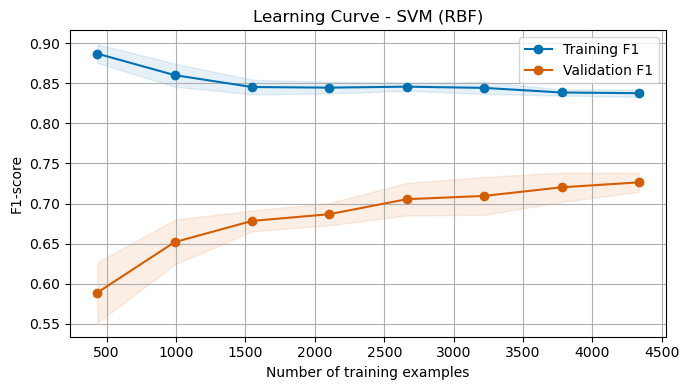

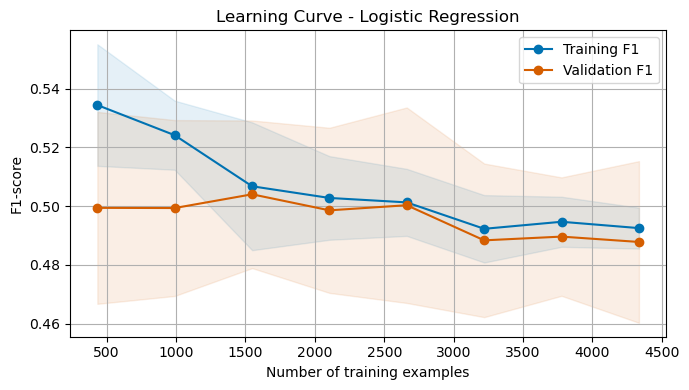

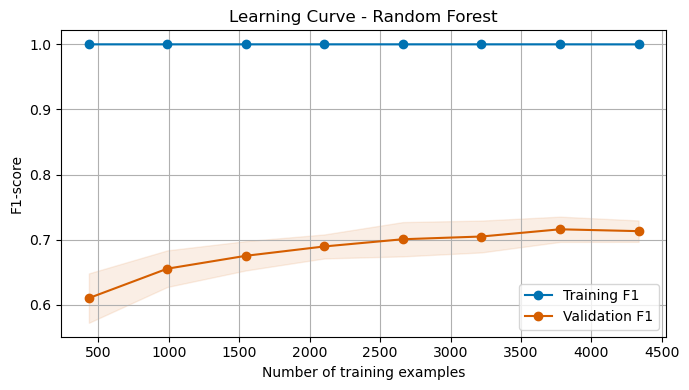

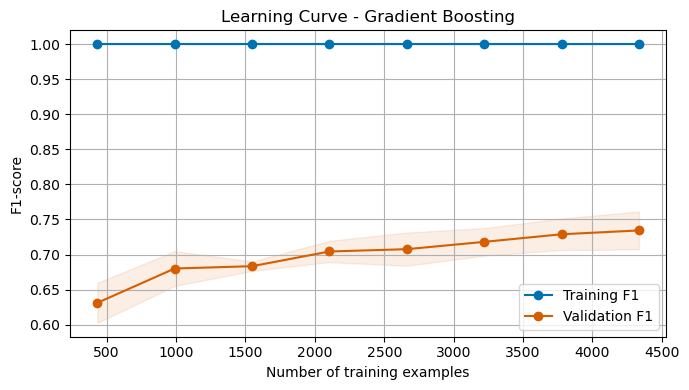

In [54]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, (model, use_scaled) in models_final.items():

    # Select the correct training data
    if use_scaled:
        X_used = X_train_s
    else:
        X_used = X_train

    # Compute the learning curve
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model.__class__(**model.get_params()),
        X=X_used,
        y=y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8),
        shuffle=True,
        random_state=42
    )

    # Mean and std
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    # Plotting
    plt.figure(figsize=(7,4))
    plt.plot(train_sizes, train_mean, "o-", label="Training F1", color="#0072B2")
    plt.plot(train_sizes, val_mean,   "o-", label="Validation F1", color="#D55E00")

    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color="#0072B2")
    plt.fill_between(train_sizes, val_mean-val_std,     val_mean+val_std,     alpha=0.1, color="#D55E00")

    plt.title(f"Learning Curve - {name}")
    plt.xlabel("Number of training examples")
    plt.ylabel("F1-score")
    plt.grid(); plt.legend(); plt.tight_layout(); plt.show()



=== SVM (RBF) – TEST PERFORMANCE ===
Accuracy:  0.8313
Precision: 0.7784
Recall:    0.6899
F1:        0.7315
AUC:       0.8933

Classification report:
              precision    recall  f1-score   support

 Non-seizure       0.85      0.90      0.88       775
     Seizure       0.78      0.69      0.73       387

    accuracy                           0.83      1162
   macro avg       0.82      0.80      0.80      1162
weighted avg       0.83      0.83      0.83      1162



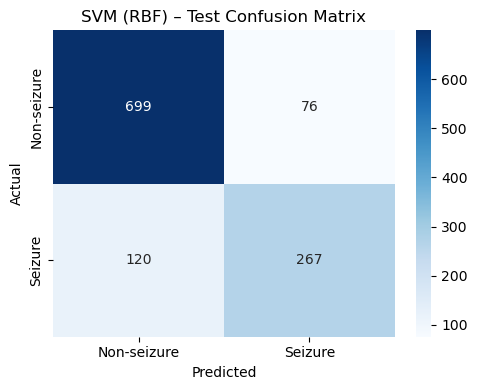


=== Logistic Regression – TEST PERFORMANCE ===
Accuracy:  0.7392
Precision: 0.7188
Recall:    0.3566
F1:        0.4767
AUC:       0.7659

Classification report:
              precision    recall  f1-score   support

 Non-seizure       0.74      0.93      0.83       775
     Seizure       0.72      0.36      0.48       387

    accuracy                           0.74      1162
   macro avg       0.73      0.64      0.65      1162
weighted avg       0.74      0.74      0.71      1162



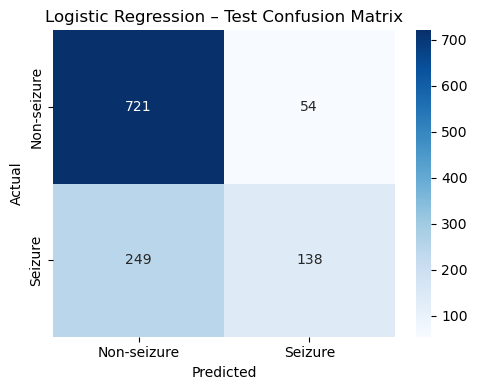


=== Random Forest – TEST PERFORMANCE ===
Accuracy:  0.8313
Precision: 0.8131
Recall:    0.6408
F1:        0.7168
AUC:       0.9130

Classification report:
              precision    recall  f1-score   support

 Non-seizure       0.84      0.93      0.88       775
     Seizure       0.81      0.64      0.72       387

    accuracy                           0.83      1162
   macro avg       0.83      0.78      0.80      1162
weighted avg       0.83      0.83      0.83      1162



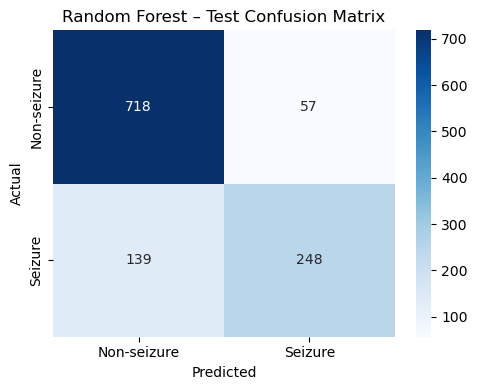


=== Gradient Boosting – TEST PERFORMANCE ===
Accuracy:  0.8520
Precision: 0.7978
Recall:    0.7442
F1:        0.7701
AUC:       0.9191

Classification report:
              precision    recall  f1-score   support

 Non-seizure       0.88      0.91      0.89       775
     Seizure       0.80      0.74      0.77       387

    accuracy                           0.85      1162
   macro avg       0.84      0.82      0.83      1162
weighted avg       0.85      0.85      0.85      1162



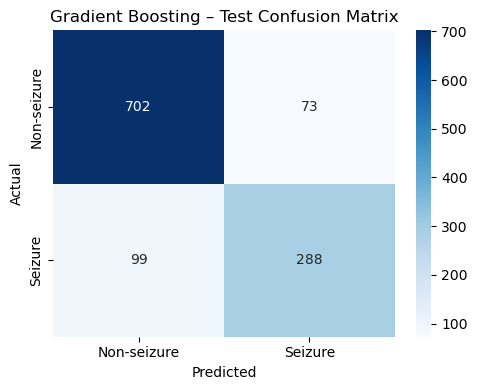


=== SUMMARY – Test Metrics for All Models ===
              Model  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_AUC
  Gradient Boosting       0.851979        0.797784     0.744186 0.770053  0.919080
          SVM (RBF)       0.831325        0.778426     0.689922 0.731507  0.893280
      Random Forest       0.831325        0.813115     0.640827 0.716763  0.912987
Logistic Regression       0.739243        0.718750     0.356589 0.476684  0.765938


In [ ]:
summary_rows = []

for name, (model, use_scaled) in models_final.items():
    if use_scaled:
        X_test_used = X_test_s
    else:
        X_test_used = X_test

    y_pred = model.predict(X_test_used)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_used)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n=== {name} - TEST PERFORMANCE ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"AUC:       {auc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["Non-seizure", "Seizure"]))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Non-seizure", "Seizure"],
                yticklabels=["Non-seizure", "Seizure"])
    plt.title(f"{name} – Test Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    summary_rows.append({
        "Model": name,
        "Test_Accuracy": acc,
        "Test_Precision": prec,
        "Test_Recall": rec,
        "Test_F1": f1,
        "Test_AUC": auc
    })

summary_df = pd.DataFrame(summary_rows)
print("\n=== SUMMARY – Test Metrics for All Models ===")
print(summary_df.sort_values("Test_F1", ascending=False).to_string(index=False))

### Extra Figures that were Produced

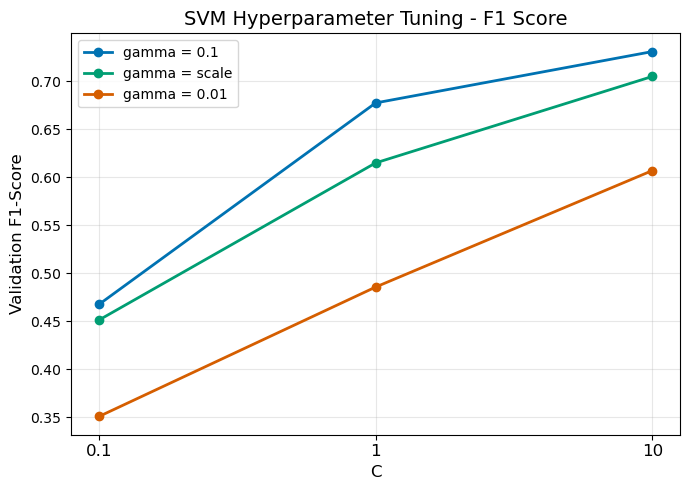

In [ ]:
# Your data
data = {
    "C":       [10.0, 10.0, 1.0, 1.0, 10.0, 1.0, 0.1, 0.1, 0.1],
    "gamma":   ["0.1", "scale", "0.1", "scale", "0.01", "0.01", "0.1", "scale", "0.01"],
    "val_f1":  [0.730769, 0.704871, 0.677326, 0.614916, 0.606918, 0.485714, 0.467626, 0.451376, 0.351020]
}

df = pd.DataFrame(data)

# Colorblind friendly palette (Okabe-Ito)
colors = ["#0072B2", "#009E73", "#D55E00", "#CC79A7"]

C_values = [0.1, 1, 10]
x_pos = np.arange(len(C_values))

plt.figure(figsize=(7,5))

# Loop with color assignment
for idx, g in enumerate(df["gamma"].unique()):
    df_g = df[df["gamma"] == g]

    # Collect F1 values in C order
    y_vals = [df_g[df_g["C"] == C]["val_f1"].values[0] for C in C_values]

    plt.plot(x_pos, y_vals, marker="o", linewidth=2,label=f"gamma = {g}", color=colors[idx % len(colors)])

plt.xticks(x_pos, C_values, fontsize=12)
plt.xlabel("C", fontsize=12); plt.ylabel("Validation F1-Score", fontsize=12)
plt.title("SVM Hyperparameter Tuning - F1 Score", fontsize=14)
plt.grid(True, alpha=0.3);plt.legend(); plt.tight_layout(); plt.show()
